# Creekside E+ — dialing A04 (dual ~287 kW + GL14)

Fictional site name **Creekside** (scrubbed `deep-research-report.md` on the site root).

## How we dialed it in

We started from the W2A **E20** dual plant (rated heating COP **5.04**, Jan‑26 peak ~271 kW, monthly GL14 just inside the gate). Softening the year‑round rated heating COP toward **4.5** (**SC02**) lifted the cold‑Monday peak into the **~290 kW** band near billed ~285, but monthly NMBE slipped to about **−9%** because winter electric rose on a fixed COP dial while summer months were already ~**+25%** high from year‑round school‑day occupancy and plug schedules. Cutting plugs and lights (**R02**: equip×0.60, lights×0.95) recovered GL14 at ~289 kW without giving up the peak. Treating **June–July** as summer‑out (short Mon–Thu summer‑school hours) while putting **August back in session**—on the bet that the school occupies about a month early—plus a better cooling COP (~4.8) fixed the August bill error (from roughly −50% when August was summer‑out to about **+2%**) and tightened September. The resulting champion **A04** holds COP 4.5, R02 internals, Jun–Jul summer×0.40, cooling COP 4.8, and August‑in‑session schedules: **~287 kW** peak, overnight ~144 kW, **NMBE ~+1.0% / CVRMSE ~10.4%**.

| Trial | Role | Peak | Aug err | GL14 | NMBE / CV |
| --- | --- | ---: | ---: | --- | --- |
| E20 | prior dual (COP 5.04) | ~271 | — | pass | −4.9% / 13.5% |
| SC02 | soft COP 4.5 only | ~290 | +26% | fail | −9.4% / 14.6% |
| R02 | SC02 + equip/lights cut | ~289 | — | pass | −1.6% / 11.0% |
| **A04** | **R02 + Jun–Jul summer + clg 4.8; Aug school** | **~287** | **+1.7%** | **pass** | **+1.0% / 10.4%** |

Set `LAKESIDE_SITE_ROOT` if needed (default Desktop `sp_creekside`).

## Gates & live knobs

**Hard gates:** utility monthly GL14 (|NMBE| &lt; 5%, CVRMSE &lt; 15%) · Jan‑26 peak toward ~285 kW · overnight 0–4 not exploding.

**A04 knobs:** cap×1.70 · heating COP 4.5 · cooling COP 4.8 · setback 7.78 °C · opt-start 3.5 h · equip×0.60 · lights×0.95 · `summer_sch_scale=0.40` (Jun–Jul only; **August in-session**).

In [1]:
%matplotlib inline
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(ROOT))

from lakeside.paths import site_root
from notebook_plots import apply_notebook_theme, save_fig, metric_cards_html
from eplus_validation_contract import build_hourly_and_15min, utility_monthly_from_trial_sim

def monthly_gl14_style_pass(util: dict) -> dict:
    nmbe, cv = util.get("nmbe_pct"), util.get("cvrmse_pct")
    ok = nmbe is not None and cv is not None and abs(float(nmbe)) < 5.0 and float(cv) < 15.0
    return {"pass": bool(ok), "nmbe_pct": nmbe, "cvrmse_pct": cv}

apply_notebook_theme()

_DEFAULT_SITE = Path(r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside")
_env = os.environ.get("LAKESIDE_SITE_ROOT") or os.environ.get("VIBE22_SITE_ROOT")
if _env:
    SITE = Path(_env)
else:
    try:
        SITE = site_root()
    except FileNotFoundError:
        SITE = _DEFAULT_SITE
if not SITE.is_dir() or not (SITE / "reports").is_dir():
    raise FileNotFoundError(
        f"Site root not found or missing reports/: {SITE}\n"
        "Set LAKESIDE_SITE_ROOT to your sp_creekside folder."
    )
os.environ["LAKESIDE_SITE_ROOT"] = str(SITE)

FIG = SITE / "plots" / "analytics" / "eplus_gl14_vs_peak285"
FIG.mkdir(parents=True, exist_ok=True)

SOFT = SITE / "eplus/campaigns/w2a_e20_soft_cop_trim_20260809T131911Z"
REC = SITE / "eplus/campaigns/w2a_sc02_gl14_recover_20260809T132941Z"
AUG = SITE / "eplus/campaigns/w2a_sc02_aug_in_session_20260809T134542Z"

E20_SIM = SITE / "eplus/campaigns/w2a_l22_enhanced_20260808T205123Z/trials/E20_peakplant_eq075_li110_cop120/sim"
SC02_SIM = SOFT / "trials/SC02_cop45/sim"
R02_SIM = REC / "trials/R02_eq060_li095/sim"
A04_SIM = AUG / "trials/A04_r02_sum040_clg48_augSchool/sim"

C = {
    "actual": "#264653",
    "e20": "#2a9d8f",
    "sc02": "#e9c46a",
    "r02": "#f4a261",
    "a04": "#e76f51",
    "gate": "#5c6b73",
}

print("SITE", SITE, "exists", SITE.is_dir())
for lab, p in [("E20", E20_SIM), ("SC02", SC02_SIM), ("R02", R02_SIM), ("A04", A04_SIM)]:
    print(lab, "ok", (p / "eplusmtr.csv").is_file(), p)
print("FIG", FIG)

SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside exists True
E20 ok True C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\campaigns\w2a_l22_enhanced_20260808T205123Z\trials\E20_peakplant_eq075_li110_cop120\sim
SC02 ok True C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\campaigns\w2a_e20_soft_cop_trim_20260809T131911Z\trials\SC02_cop45\sim
R02 ok True C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\campaigns\w2a_sc02_gl14_recover_20260809T132941Z\trials\R02_eq060_li095\sim
A04 ok True C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\campaigns\w2a_sc02_aug_in_session_20260809T134542Z\trials\A04_r02_sum040_clg48_augSchool\sim
FIG C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285


## Load sims + scorecards

E20 → SC02 → R02 → **A04** progression against BAS intervals and utility monthly GL14.

In [2]:
def pack_model(label: str, sim: Path):
    packed = build_hourly_and_15min(SITE, sim, heat_cop=3.5, cool_cop=4.5)
    util = utility_monthly_from_trial_sim(SITE, sim, heat_cop=3.5, cool_cop=4.5)
    hold = monthly_gl14_style_pass(util)
    q = packed["q15"].copy()
    q["interval_end_utc"] = pd.to_datetime(q["interval_end_utc"], utc=True)
    local = q["interval_end_utc"].dt.tz_convert("America/Chicago")
    q = q.assign(
        local=local,
        hod=local.dt.hour + local.dt.minute / 60.0,
        d=local.dt.strftime("%Y-%m-%d"),
        month=local.dt.strftime("%Y-%m"),
        dow=local.dt.dayofweek,
    )
    h = packed["hourly"].copy()
    h["interval_end_utc"] = pd.to_datetime(h["interval_end_utc"], utc=True)
    hl = h["interval_end_utc"].dt.tz_convert("America/Chicago")
    h = h.assign(local=hl, month=hl.dt.strftime("%Y-%m"), hour=hl.dt.hour, dow=hl.dt.dayofweek)
    pairs = pd.DataFrame(util["monthly_pairs"]).assign(model=label)
    pairs["err_pct"] = (pairs["kwh_sim"] - pairs["kwh_obs"]) / pairs["kwh_obs"] * 100.0
    return {
        "label": label,
        "q15": q,
        "hourly": h,
        "util": util,
        "hold": hold,
        "pairs": pairs,
    }

e20 = pack_model("E20", E20_SIM)
sc02 = pack_model("SC02", SC02_SIM)
r02 = pack_model("R02", R02_SIM)
a04 = pack_model("A04", A04_SIM)

MODELS = [
    ("E20", e20, C["e20"]),
    ("SC02", sc02, C["sc02"]),
    ("R02", r02, C["r02"]),
    ("A04", a04, C["a04"]),
]

day = "2026-01-26"
days = {lab: pack["q15"][pack["q15"]["d"] == day] for lab, pack, _ in MODELS}

def _peak(lab):
    return float(days[lab]["simulated_kw"].max())

def _ov(lab):
    d = days[lab]
    return float(d[(d["hod"] >= 0) & (d["hod"] < 4)]["simulated_kw"].mean())

display(HTML(metric_cards_html([
    {"label": "E20 NMBE / peak", "value": f"{e20['util']['nmbe_pct']:+.1f}%", "sub": f"{_peak('E20'):.0f} kW"},
    {"label": "SC02 COP4.5", "value": f"{sc02['util']['nmbe_pct']:+.1f}%", "sub": f"{_peak('SC02'):.0f} kW · bills fail"},
    {"label": "R02 recover", "value": f"{r02['util']['nmbe_pct']:+.1f}%", "sub": f"{_peak('R02'):.0f} kW · GL14"},
    {"label": "A04 champion", "value": f"{a04['util']['nmbe_pct']:+.1f}%", "sub": f"{_peak('A04'):.0f} kW · dual"},
    {"label": "A04 overnight", "value": f"{_ov('A04'):.0f} kW", "sub": "0–4 on Jan-26"},
    {"label": "A04 vs 285", "value": f"{_peak('A04')-285:+.0f} kW", "sub": "peak vs utility billed"},
], title="Dial progression — E20 → SC02 → R02 → A04")))

## Peak day — 2026-01-26

Actual BAS vs E20 / SC02 / R02 / **A04**.

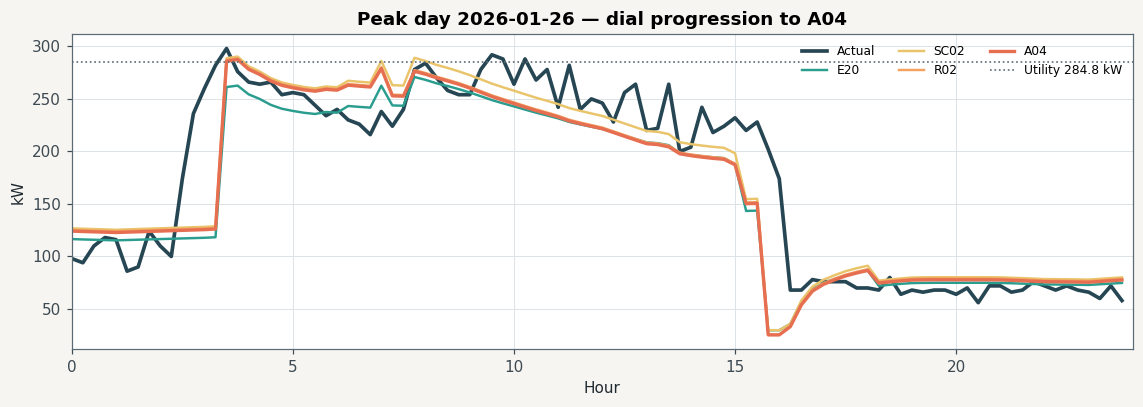

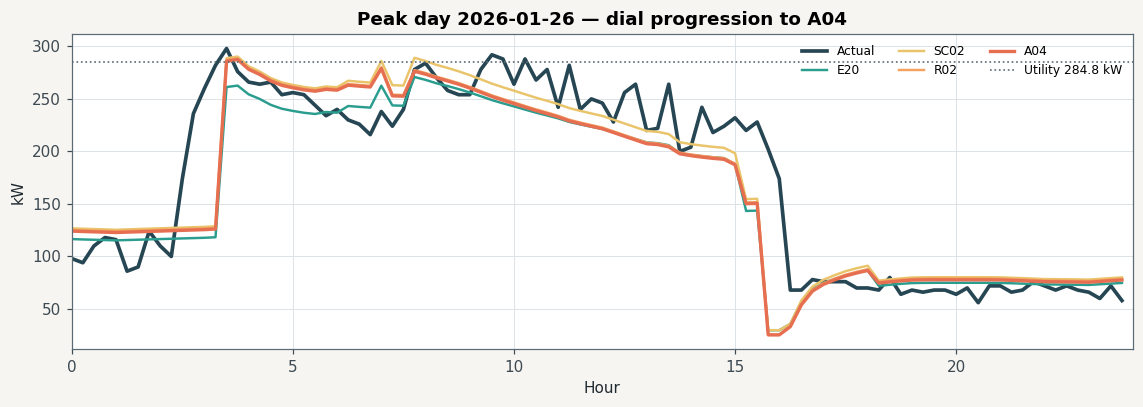

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 3.8))
d0 = days["E20"]
ax.plot(d0["hod"], d0["observed_kw"], color=C["actual"], lw=2.4, label="Actual")
for lab, pack, col in MODELS:
    d = days[lab]
    ax.plot(d["hod"], d["simulated_kw"], color=col, lw=2.2 if lab == "A04" else 1.6, label=lab)
ax.axhline(284.82, color=C["gate"], ls=":", lw=1.1, label="Utility 284.8 kW")
ax.set_xlim(0, 24)
ax.set_xlabel("Hour")
ax.set_ylabel("kW")
ax.set_title(f"Peak day {day} — dial progression to A04")
ax.legend(loc="upper right", fontsize=8, frameon=False, ncol=3)
fig.tight_layout()
save_fig(FIG / "peak_day_e20_sc02_r02_a04.png", fig)
plt.show()

## Winter shapes — weekday vs weekend

Dec–Feb mean profiles: **actual** vs the dial ladder.

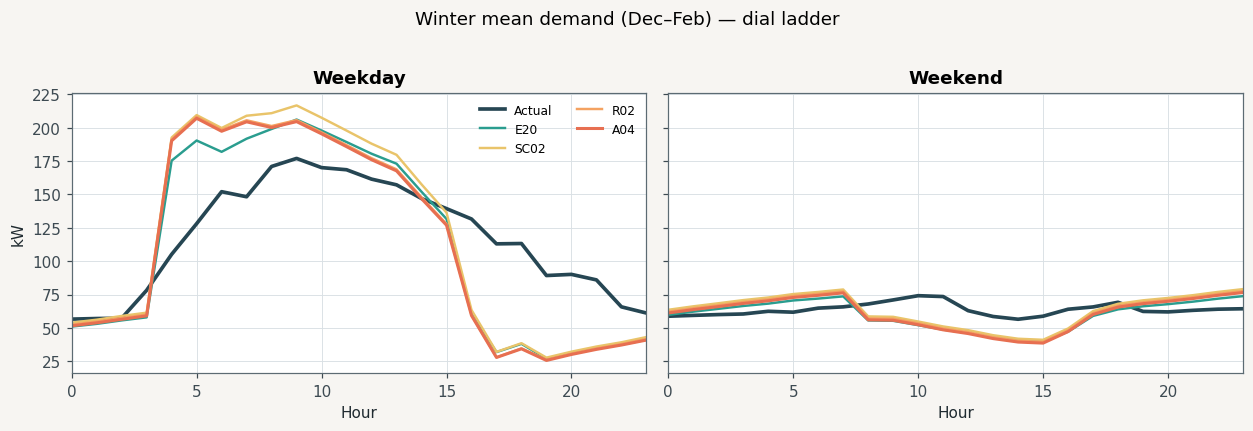

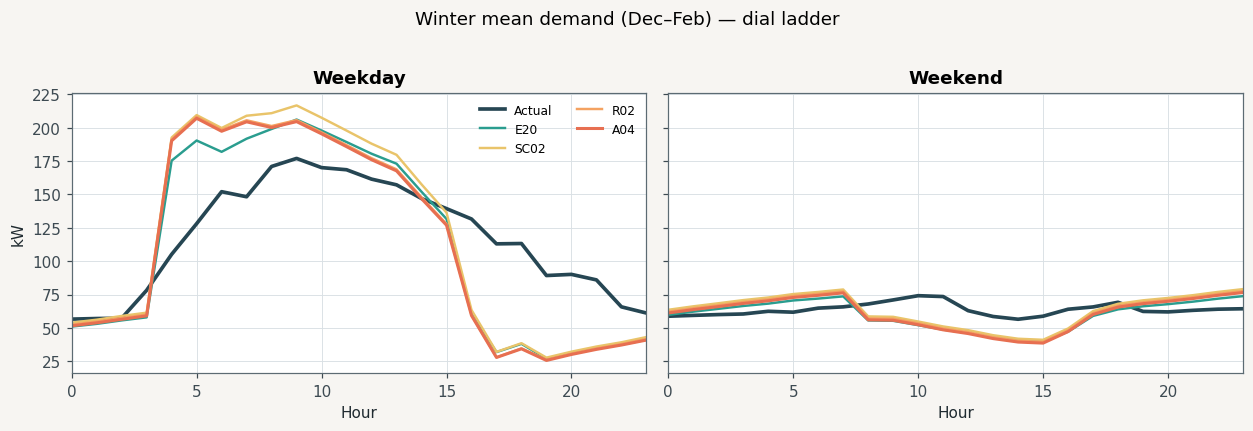

In [4]:
SHAPE_WINDOWS = {
    "Base load": (0, 4),
    "Morning ramp": (5, 9),
    "Afternoon": (10, 15),
    "Evening setback": (16, 21),
}


def winter_slice(hourly: pd.DataFrame, *, weekend: bool) -> pd.DataFrame:
    m = hourly["local"].dt.month.isin([12, 1, 2])
    dmask = hourly["dow"].isin([5, 6]) if weekend else hourly["dow"].between(0, 4)
    return hourly.loc[m & dmask].copy()


def mean_profile(hourly: pd.DataFrame, *, weekend: bool) -> pd.DataFrame:
    s = winter_slice(hourly, weekend=weekend)
    g = s.groupby("hour")
    return pd.DataFrame({"obs": g["observed_kw"].mean(), "sim": g["simulated_kw"].mean()})


def shape_closeness(hourly: pd.DataFrame, *, weekend: bool) -> dict:
    s = winter_slice(hourly, weekend=weekend)
    out = {}
    for name, (h0, h1) in SHAPE_WINDOWS.items():
        w = s[s["hour"].between(h0, h1)]
        obs = float(w["observed_kw"].mean())
        sim = float(w["simulated_kw"].mean())
        pct_err = (sim - obs) / obs * 100.0
        out[name] = {
            "obs_kw": obs,
            "sim_kw": sim,
            "pct_error": pct_err,
            "closeness_pct": max(0.0, 100.0 - abs(pct_err)),
        }
    g = s.groupby("hour")
    obs_p, sim_p = g["observed_kw"].mean(), g["simulated_kw"].mean()
    mae = float(np.mean(np.abs(sim_p - obs_p)))
    obs_mean = float(obs_p.mean())
    out["Full-day"] = {
        "obs_kw": obs_mean,
        "sim_kw": float(sim_p.mean()),
        "pct_error": (float(sim_p.mean()) - obs_mean) / obs_mean * 100.0,
        "closeness_pct": max(0.0, 100.0 - 100.0 * mae / obs_mean),
    }
    return out


fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
for ax, weekend, title in [(axes[0], False, "Weekday"), (axes[1], True, "Weekend")]:
    pref = mean_profile(e20["hourly"], weekend=weekend)
    ax.plot(pref.index, pref["obs"], color=C["actual"], lw=2.4, label="Actual")
    for lab, pack, col in MODELS:
        p = mean_profile(pack["hourly"], weekend=weekend)
        ax.plot(p.index, p["sim"], color=col, lw=2.0 if lab == "A04" else 1.6, label=lab)
    ax.set_title(title)
    ax.set_xlim(0, 23)
    ax.set_xlabel("Hour")
axes[0].set_ylabel("kW")
axes[0].legend(loc="upper right", fontsize=8, ncol=2, frameon=False)
fig.suptitle("Winter mean demand (Dec–Feb) — dial ladder", y=1.02, fontsize=12)
fig.tight_layout()
save_fig(FIG / "winter_wd_we_profiles_a04_ladder.png", fig)
plt.show()

rows = []
for day_label, weekend in [("weekday", False), ("weekend", True)]:
    for lab, pack, _ in MODELS:
        for comp, m in shape_closeness(pack["hourly"], weekend=weekend).items():
            rows.append({
                "day_type": day_label,
                "model": lab,
                "component": comp,
                "closeness_pct": m["closeness_pct"],
                "pct_error": m["pct_error"],
                "obs_kw": m["obs_kw"],
                "sim_kw": m["sim_kw"],
            })
shape_df = pd.DataFrame(rows)
shape_df.to_csv(FIG / "winter_shape_closeness_a04_ladder.csv", index=False)

## Shape closeness % — base / morning / afternoon / evening

`closeness% = 100 − |sim−obs|/obs×100` (clipped at 0).

**Weekday closeness %**

model,E20,SC02,R02,A04
component,,,,
Base load,89.1,80.6,82.6,84.0
Morning ramp,75.2,65.3,68.7,69.5
Afternoon,91.4,86.9,93.5,94.2
Evening setback,35.8,36.9,34.3,33.9
Full-day,70.3,66.5,68.3,68.4


**Weekend closeness %**

model,E20,SC02,R02,A04
component,,,,
Base load,93.4,86.5,88.8,90.6
Morning ramp,98.7,94.9,97.1,98.8
Afternoon,70.2,73.3,71.0,69.4
Evening setback,96.7,97.0,99.3,99.1
Full-day,83.8,81.7,81.9,82.0


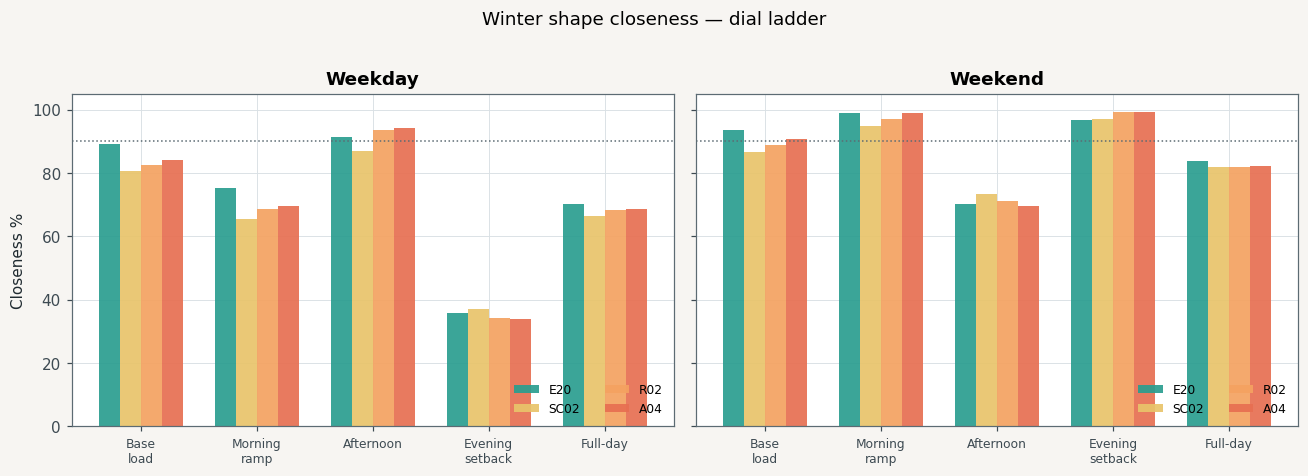

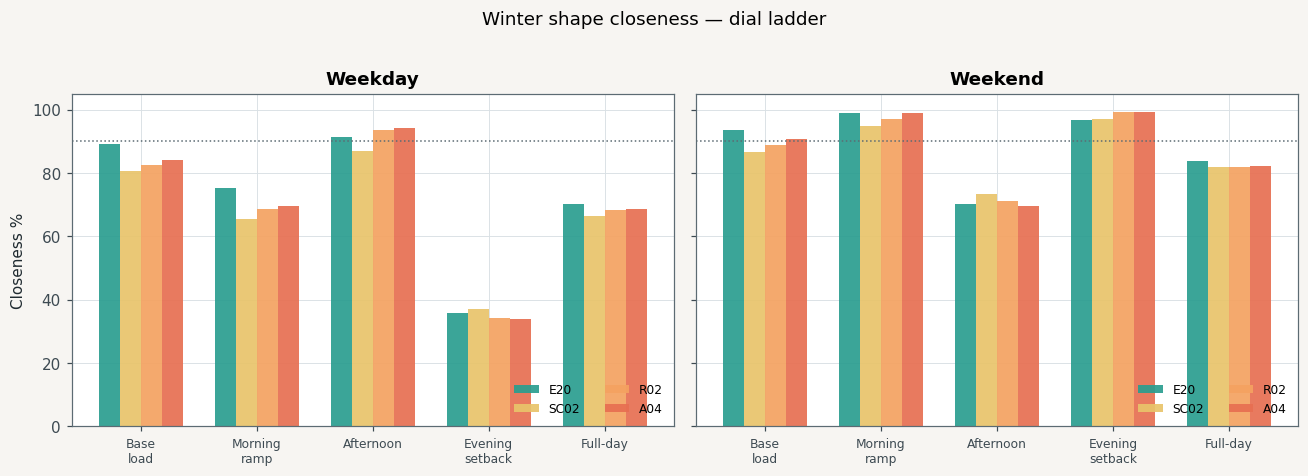

In [5]:
comp_order = list(SHAPE_WINDOWS.keys()) + ["Full-day"]
model_order = [m[0] for m in MODELS]
colors = {m[0]: m[2] for m in MODELS}

wd = (
    shape_df[shape_df["day_type"] == "weekday"]
    .pivot(index="component", columns="model", values="closeness_pct")
    .reindex(comp_order)[model_order]
)
we = (
    shape_df[shape_df["day_type"] == "weekend"]
    .pivot(index="component", columns="model", values="closeness_pct")
    .reindex(comp_order)[model_order]
)

display(Markdown("**Weekday closeness %**"))
try:
    display(wd.round(1).style.background_gradient(cmap="YlGn", vmin=0, vmax=100).format("{:.1f}"))
except Exception:
    display(wd.round(1))

display(Markdown("**Weekend closeness %**"))
try:
    display(we.round(1).style.background_gradient(cmap="YlGn", vmin=0, vmax=100).format("{:.1f}"))
except Exception:
    display(we.round(1))

x = np.arange(len(comp_order))
width = 0.18
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
for ax, table, title in [(axes[0], wd, "Weekday"), (axes[1], we, "Weekend")]:
    for i, model in enumerate(model_order):
        vals = [float(table.loc[c, model]) for c in comp_order]
        ax.bar(x + (i - 1.5) * width, vals, width, label=model, color=colors[model], alpha=0.92)
    ax.axhline(90, color=C["gate"], ls=":", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace(" ", "\n") for c in comp_order], fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8, frameon=False, ncol=2)
axes[0].set_ylabel("Closeness %")
fig.suptitle("Winter shape closeness — dial ladder", y=1.02, fontsize=12)
fig.tight_layout()
save_fig(FIG / "winter_shape_component_closeness_a04.png", fig)
plt.show()

## Monthly utility kWh — GL14 path

SC02 over-predicts winter; R02/A04 claw bills back. A04’s August-in-session + Jun–Jul summer cut flattens Aug/Sep.

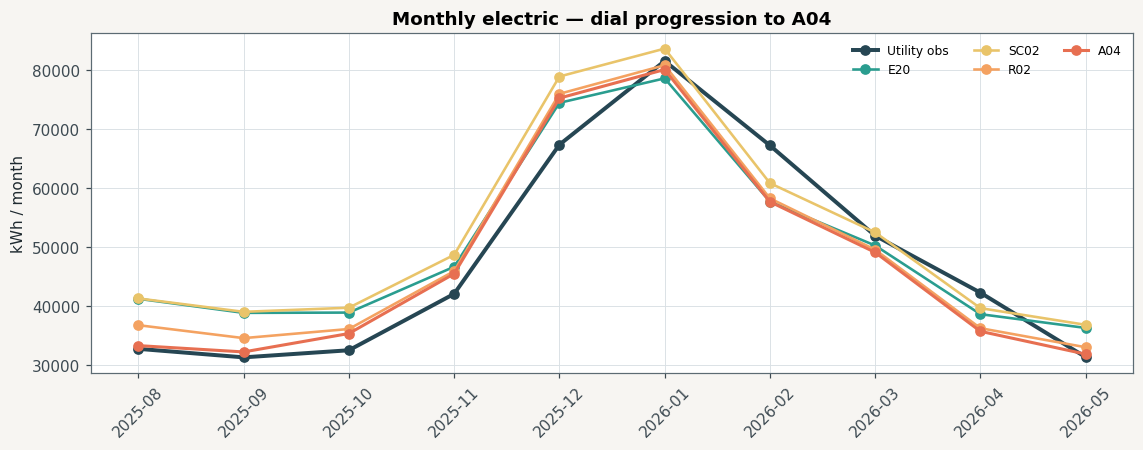

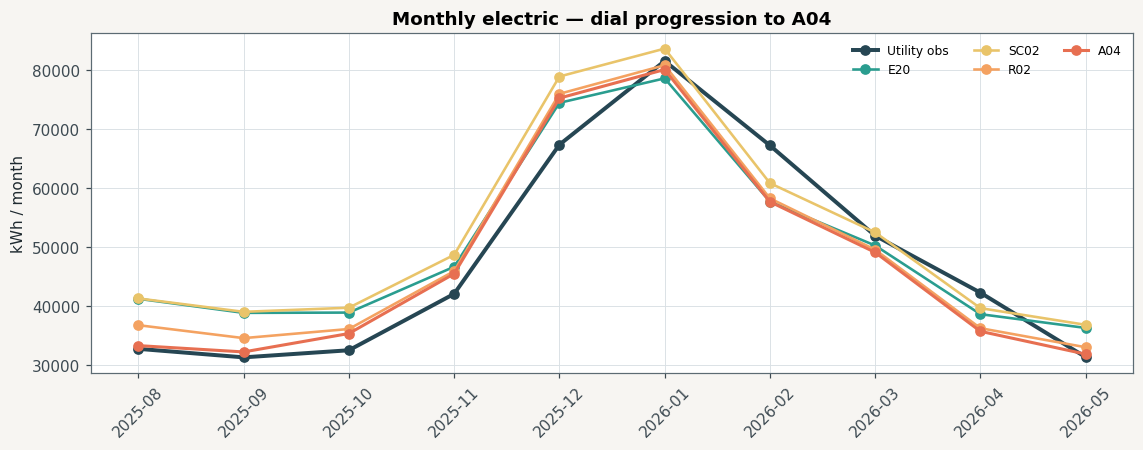

**Month error %** `(sim−obs)/obs`

,obs_kWh,E20,SC02,R02,A04
month,,,,,
2025-08,32789.0,25.8,26.0,12.2,1.7
2025-09,31350.0,24.0,24.6,10.4,2.9
2025-10,32552.0,19.6,22.1,11.1,8.7
2025-11,42097.0,10.9,15.7,9.1,8.1
2025-12,67328.0,10.5,17.1,12.8,11.7
2026-01,81491.0,-3.6,2.6,-0.9,-1.8
2026-02,67205.0,-14.1,-9.5,-13.3,-14.2
2026-03,51938.0,-3.2,1.1,-4.6,-5.4
2026-04,42296.0,-8.6,-6.2,-14.2,-15.5


,model,nmbe_pct,cvrmse_pct,gl14,jan26_peak_kw,overnight_0_4_kw
0,E20,-4.91,13.52,PASS,270.8,134.7
1,SC02,-9.41,14.59,FAIL,290.3,147.1
2,R02,-1.60,11.05,PASS,288.6,145.6
3,A04,0.98,10.45,PASS,287.5,144.5


wrote C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285\a04_dial_scorecard.csv


In [6]:
months = sorted(e20["pairs"]["month"].unique())
obs = e20["pairs"].set_index("month").reindex(months)["kwh_obs"]

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.plot(months, obs, color=C["actual"], lw=2.6, marker="o", label="Utility obs")
for lab, pack, col in MODELS:
    s = pack["pairs"].set_index("month").reindex(months)["kwh_sim"]
    ax.plot(months, s, color=col, lw=2.0 if lab == "A04" else 1.7, marker="o", label=lab)
ax.set_ylabel("kWh / month")
ax.set_title("Monthly electric — dial progression to A04")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="best", fontsize=8, frameon=False, ncol=3)
fig.tight_layout()
save_fig(FIG / "monthly_kwh_line_a04_ladder.png", fig)
plt.show()

err = pd.DataFrame({"obs_kWh": obs})
for lab, pack, _ in MODELS:
    s = pack["pairs"].set_index("month").reindex(months)
    err[lab] = ((s["kwh_sim"] - s["kwh_obs"]) / s["kwh_obs"] * 100.0).round(1)
display(Markdown("**Month error %** `(sim−obs)/obs`"))
display(err)

rows = []
for lab, pack, _ in MODELS:
    rows.append({
        "model": lab,
        "nmbe_pct": round(float(pack["util"]["nmbe_pct"]), 2),
        "cvrmse_pct": round(float(pack["util"]["cvrmse_pct"]), 2),
        "gl14": "PASS" if pack["hold"]["pass"] else "FAIL",
        "jan26_peak_kw": round(_peak(lab), 1),
        "overnight_0_4_kw": round(_ov(lab), 1),
    })
score = pd.DataFrame(rows)
display(score)
score.to_csv(FIG / "a04_dial_scorecard.csv", index=False)
print("wrote", FIG / "a04_dial_scorecard.csv")

## End-use estimate — A04 champion

Lights / plugs / HVAC residual stack for **A04** (~287 kW dual).

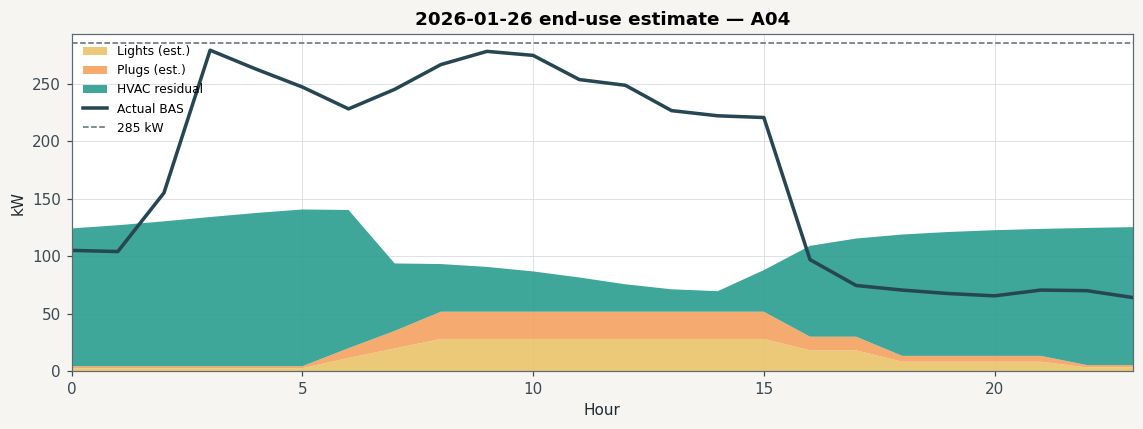

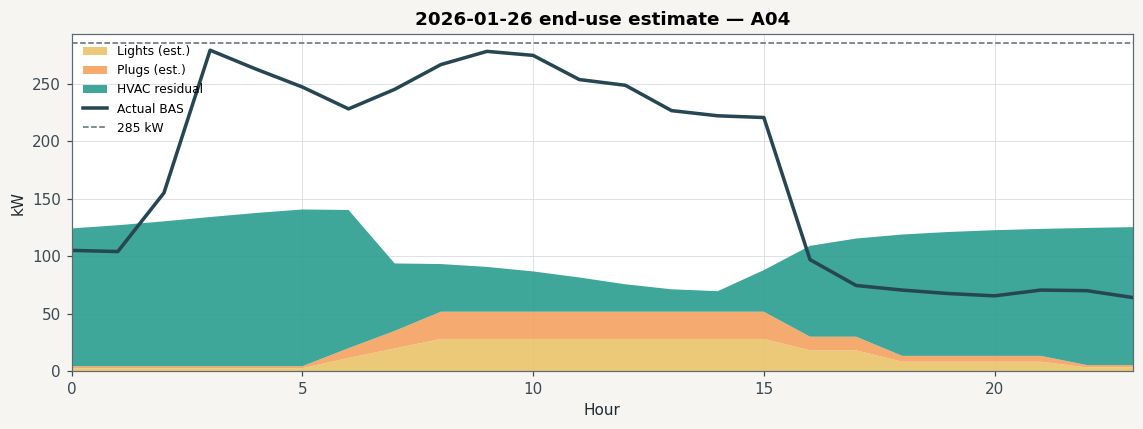

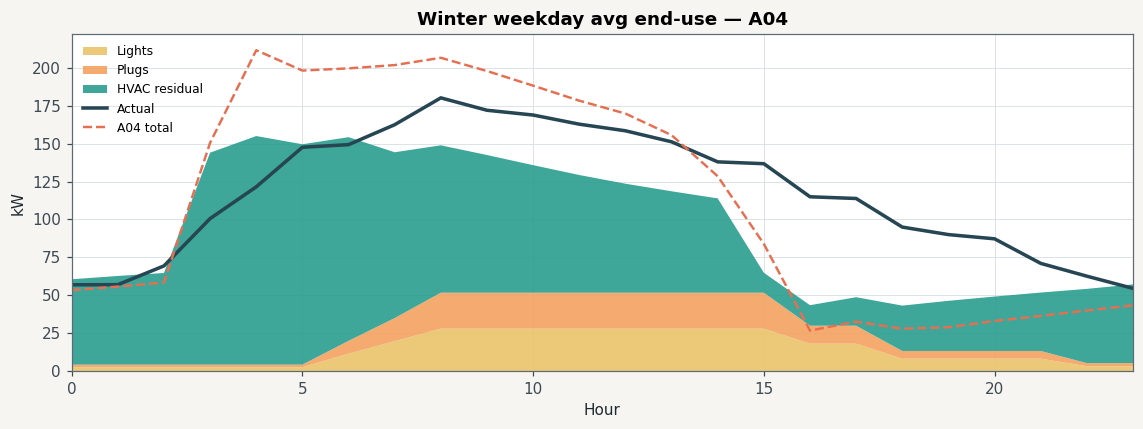

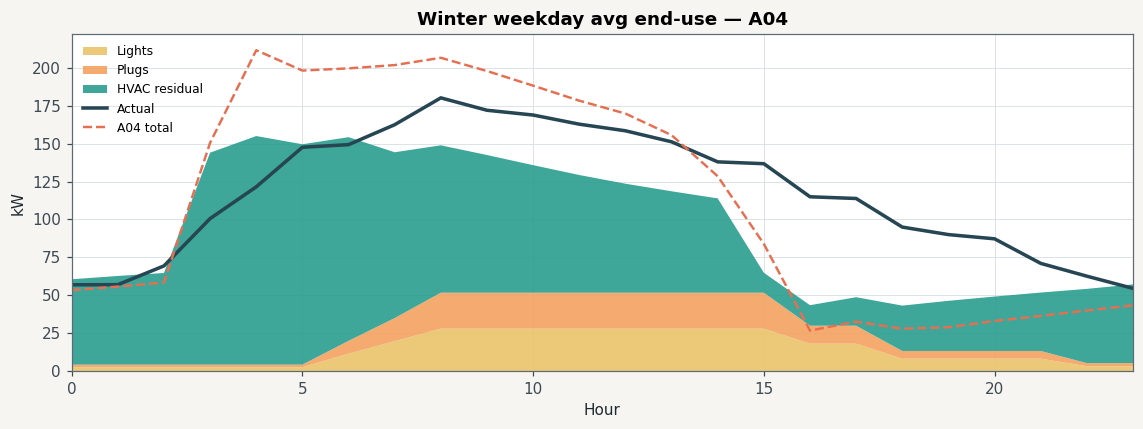

### Soft COP `w2a_e20_soft_cop_trim_20260809T131911Z` · GL14 passers=0 · dual=[]

,trial_id,status,jan26_peak_kw,overnight_0_4_sim_kw,gl14_pass,nmbe_pct,cvrmse_pct
0,SC01_cop47,ok_gl14_fail,281.85,142.21,False,-7.62,13.91
1,SC02_cop45,ok_gl14_fail,290.32,147.14,False,-9.41,14.59
2,SC03_cop40,ok_gl14_fail,322.57,161.63,False,-14.65,18.13


### SC02 recover `w2a_sc02_gl14_recover_20260809T132941Z` · GL14 passers=4 · dual=['R02_eq060_li095', 'R01_eq065_li100', 'R04_eq065_li100_opt25', 'R03_eq065_li100_sb7']

,trial_id,status,jan26_peak_kw,overnight_0_4_sim_kw,gl14_pass,nmbe_pct,cvrmse_pct
0,R01_eq065_li100,ok_dual_peak,289.19,146.12,True,-4.20,11.82
1,R02_eq060_li095,ok_dual_peak,288.63,145.62,True,-1.60,11.05
2,R03_eq065_li100_sb7,ok_dual_peak,292.15,142.83,True,-2.76,11.61
3,R04_eq065_li100_opt25,ok_dual_peak,290.13,126.19,True,-1.21,11.51
4,R05_eq070_li100,ok_gl14_fail,289.51,146.41,False,-5.46,12.36


### Aug in-session `w2a_sc02_aug_in_session_20260809T134542Z` · GL14 passers=3 · dual=['A04_r02_sum040_clg48_augSchool', 'A03_r02_sum025_clg46_augSchool', 'A05_eq065_li100_sum025_clg46']

,trial_id,status,jan26_peak_kw,overnight_0_4_sim_kw,gl14_pass,nmbe_pct,cvrmse_pct,err_pct_2025-08,err_pct_2025-09
0,A01_sc02_sum025_clg46_augSchool,ok_gl14_fail,289.31,146.13,False,-6.95,12.67,15.95,17.24
1,A02_sc02_sum025_clg46_hvac_augSchool,ok_gl14_fail,289.31,146.13,False,-6.95,12.67,15.95,17.24
2,A03_r02_sum025_clg46_augSchool,ok_dual_peak,287.62,144.61,True,0.68,10.47,2.91,3.80
3,A04_r02_sum040_clg48_augSchool,ok_dual_peak,287.49,144.47,True,0.98,10.45,1.67,2.93
4,A05_eq065_li100_sum025_clg46,ok_dual_peak,288.18,145.12,True,-1.86,10.70,7.25,8.29


In [7]:
champ_label = "A04"
champ_sim = A04_SIM
champ = a04
q = champ["q15"].copy()

mtr = pd.read_csv(champ_sim / "eplusmtr.csv")
fac_j = pd.to_numeric(mtr["Electricity:Facility [J](Hourly)"], errors="coerce").dropna().reset_index(drop=True)
li_j = float(pd.to_numeric(mtr["InteriorLights:Electricity [J](Monthly)"], errors="coerce").dropna().sum())
eq_j = float(pd.to_numeric(mtr["InteriorEquipment:Electricity [J](Monthly)"], errors="coerce").dropna().sum())
n = len(fac_j)
hours = np.arange(n)
hod = hours % 24

def _frac(h, kind):
    if kind == "lights":
        f = np.where(h < 6, 0.08, 0.0)
        f = np.where((h >= 6) & (h < 8), 0.35 + 0.25 * (h - 6), f)
        f = np.where((h >= 8) & (h < 16), 0.85, f)
        f = np.where((h >= 16) & (h < 18), 0.55, f)
        f = np.where((h >= 18) & (h < 22), 0.25, f)
        f = np.where(h >= 22, 0.10, f)
    else:
        f = np.where(h < 6, 0.05, 0.0)
        f = np.where((h >= 6) & (h < 8), 0.25 + 0.20 * (h - 6), f)
        f = np.where((h >= 8) & (h < 16), 0.70, f)
        f = np.where((h >= 16) & (h < 18), 0.35, f)
        f = np.where((h >= 18) & (h < 22), 0.15, f)
        f = np.where(h >= 22, 0.06, f)
    f = f.astype(float)
    return f / f.sum()

lights_kw = _frac(hod, "lights") * li_j / 3.6e6
equip_kw = _frac(hod, "equip") * eq_j / 3.6e6
fac_kw = fac_j.to_numpy(dtype=float) / 3.6e6
hvac_kw = np.clip(fac_kw - lights_kw - equip_kw, 0, None)

h = q.copy()
h["hour_utc"] = h["interval_end_utc"].dt.floor("h")
hourly = (
    h.groupby("hour_utc", as_index=False)
    .agg(observed_kw=("observed_kw", "mean"), simulated_kw=("simulated_kw", "mean"))
)
local_h = hourly["hour_utc"].dt.tz_convert("America/Chicago")
hourly = hourly.assign(
    d=local_h.dt.strftime("%Y-%m-%d"),
    hod=local_h.dt.hour,
    month=local_h.dt.month,
    dow=local_h.dt.dayofweek,
)
n_use = min(len(hourly), n)
hourly = hourly.iloc[:n_use].copy()
hourly["lights_kw"] = lights_kw[:n_use]
hourly["equip_kw"] = equip_kw[:n_use]
hourly["hvac_est_kw"] = hvac_kw[:n_use]

peak = hourly[hourly["d"] == "2026-01-26"]
fig, ax = plt.subplots(figsize=(10.5, 4.0))
if len(peak):
    ax.stackplot(
        peak["hod"],
        peak["lights_kw"],
        peak["equip_kw"],
        peak["hvac_est_kw"],
        labels=["Lights (est.)", "Plugs (est.)", "HVAC residual"],
        colors=["#e9c46a", "#f4a261", "#2a9d8f"],
        alpha=0.9,
    )
    ax.plot(peak["hod"], peak["observed_kw"], color=C["actual"], lw=2.3, label="Actual BAS")
    ax.axhline(285, color=C["gate"], ls="--", lw=1, label="285 kW")
    ax.set_xlim(0, 23)
    ax.set_xlabel("Hour")
    ax.set_ylabel("kW")
    ax.set_title(f"2026-01-26 end-use estimate — {champ_label}")
    ax.legend(loc="upper left", fontsize=8, frameon=False)
fig.tight_layout()
save_fig(FIG / f"peak_day_enduse_stack_{champ_label}.png", fig)
plt.show()

winter = hourly[(hourly["month"].isin([12, 1, 2])) & (hourly["dow"] < 5)]
avg = winter.groupby("hod", as_index=False).mean(numeric_only=True)
fig, ax = plt.subplots(figsize=(10.5, 4.0))
if len(avg):
    ax.stackplot(
        avg["hod"],
        avg["lights_kw"],
        avg["equip_kw"],
        avg["hvac_est_kw"],
        labels=["Lights", "Plugs", "HVAC residual"],
        colors=["#e9c46a", "#f4a261", "#2a9d8f"],
        alpha=0.9,
    )
    ax.plot(avg["hod"], avg["observed_kw"], color=C["actual"], lw=2.3, label="Actual")
    ax.plot(avg["hod"], avg["simulated_kw"], color=C["a04"], lw=1.6, ls="--", label=f"{champ_label} total")
    ax.set_xlim(0, 23)
    ax.set_xlabel("Hour")
    ax.set_ylabel("kW")
    ax.set_title(f"Winter weekday avg end-use — {champ_label}")
    ax.legend(loc="upper left", fontsize=8, frameon=False)
fig.tight_layout()
save_fig(FIG / f"winter_wd_avg_enduse_{champ_label}.png", fig)
plt.show()

# Campaign tables
for title, path in [
    ("Soft COP", SOFT / "summary.json"),
    ("SC02 recover", REC / "summary.json"),
    ("Aug in-session", AUG / "summary.json"),
]:
    if path.is_file():
        s = json.loads(path.read_text(encoding="utf-8"))
        display(Markdown(
            f"### {title} `{s.get('campaign_id')}` · "
            f"GL14 passers={s.get('gl14_passers')} · dual={s.get('dual_peak') or s.get('dual_candidates')}"
        ))
        trials = pd.DataFrame(s.get("trials") or [])
        if len(trials):
            show = trials.copy()
            for c in ("jan26_peak_kw", "overnight_0_4_sim_kw", "nmbe_pct", "cvrmse_pct",
                      "err_pct_2025-08", "err_pct_2025-09"):
                if c in show.columns:
                    show[c] = pd.to_numeric(show[c], errors="coerce").round(2)
            cols = [c for c in (
                "trial_id", "status", "jan26_peak_kw", "overnight_0_4_sim_kw",
                "gl14_pass", "nmbe_pct", "cvrmse_pct", "err_pct_2025-08", "err_pct_2025-09",
            ) if c in show.columns]
            display(show[cols])